<a href="https://colab.research.google.com/github/facundoandrisani/EEG_Analisis_estadistico_Grupo_1/blob/main/EEG_An%C3%A1lisis_estad%C3%ADstico_Grupo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install pyedflib
# !pip install pandas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyedflib import highlevel
from scipy.stats import norm, laplace, gamma, rayleigh

In [ ]:
edf_file = "chb09_06.edf"

signals, signal_headers, header = highlevel.read_edf(edf_file)

fs = 256

num_channels = len(signals)

seizure_start_sec = 12231
seizure_end_sec = 12295

crisis_duration_sec = seizure_end_sec - seizure_start_sec

seizure_start = int(seizure_start_sec * fs)
seizure_end = int(seizure_end_sec * fs)

before_sec = 120
after_sec = 120

before_start = max(0, seizure_start - int(before_sec * fs))
after_end = min(signals[0].shape[0], seizure_end + int(after_sec * fs))

In [ ]:
# Rutina: segmentación de la señal EEG en before, crisis, after y total
# Precondición:
#   - 'signals' contiene al menos 'num_channels' señales.
#   - 'before_start', 'seizure_start', 'seizure_end', 'after_end' son índices válidos dentro de cada señal.
#   - Cada señal es un array de datos numéricos.
# Postcondición:
#   - Se construye el diccionario 'segments' con claves = número de canal.
#   - Para cada canal se almacenan las señales segmentadas ('before', 'crisis', 'after', 'total')
# Invariante:
#   - Para todo canal 'ch', las claves 'before', 'crisis', 'after' y 'total' existen en segments[ch].
# Complejidad:
#   - Tiempo: O(N) por canal, siendo N la cantidad de muestras entre 'before_start' y 'after_end'.
# La complejidad viene de recorrer los canalos num_channels por lo tanto introducir aleatoriedad
# no reduce el número de operaciones necesarias ni optimiza el cálculo
# por lo tanto usar random no mejora la complejidad, porque la tarea requiere procesar todos los datos de todas formas.


segments = {ch: {} for ch in range(num_channels)}

for ch in range(num_channels):
    signal = signals[ch]

    before = signal[before_start:seizure_start]
    before -= np.mean(before)
    segments[ch]['before'] = before

    crisis = signal[seizure_start:seizure_end]
    crisis -= np.mean(crisis)
    segments[ch]['crisis'] = crisis

    after = signal[seizure_end:after_end]
    after -= np.mean(after)
    segments[ch]['after'] = after

    total = signal[before_start:after_end]
    total -= np.mean(total)
    segments[ch]['total'] = total

In [ ]:
# Rutina: compute_descriptors(segment)
# Precondición:
#   - 'segment' es un array (o lista) numérico unidimensional.
# Postcondición:
#   - Devuelve un diccionario con descriptores univariados de la señal:
#     varianza, desv. estándar, media absoluta, autocorrelacion, autocovarianza y corr de Pearson.
# Invariante:
#   - Los cálculos se hacen de forma consistente con definiciones estadísticasde numpy, por ejemplo np.mean().
# Complejidad:
#   - Tiempo: O(N), donde N = len(segment).
# Tanto compute_descriptors como compute_biv_descriptors recorren los arrays de entrada para calcular estadísticas (O(N))
# Usar random solo agregaria costos y no reduciria la complejidad, además de comprometer la precisión de los descriptores.

def compute_descriptors(segment):
    if len(segment) == 0:
        return {
            'var': np.nan,
            'std': np.nan,
            'mean_abs': np.nan,
            'autocorr_lag1': np.nan,
            'autocov_lag1': np.nan,
            'pearson_corr_lag1': np.nan
        }

    var = np.var(segment)
    std = np.std(segment)
    mean_abs = np.mean(np.abs(segment))

    if len(segment) > 1:
        mean_seg = np.mean(segment)
        autocov_lag0 = np.mean((segment - mean_seg)**2)
        autocov_lag1 = np.mean((segment[:-1] - mean_seg) * (segment[1:] - mean_seg))
        autocorr_lag1 = autocov_lag1 / autocov_lag0 if autocov_lag0 != 0 else np.nan


        pearson_corr_lag1 = np.corrcoef(segment[:-1], segment[1:])[0, 1]
    else:
        autocorr_lag1 = np.nan
        autocov_lag1 = np.nan
        pearson_corr_lag1 = np.nan

    return {
        'var': var,
        'std': std,
        'mean_abs': mean_abs,
        'autocorr_lag1': autocorr_lag1,
        'autocov_lag1': autocov_lag1,
        'pearson_corr_lag1': pearson_corr_lag1
    }

desc_df = pd.DataFrame()

for ch in range(num_channels):
    for block in ['before', 'crisis', 'after']:
        desc = compute_descriptors(segments[ch][block])
        desc['channel'] = ch
        desc['block'] = block
        desc_df = pd.concat([desc_df, pd.DataFrame([desc])], ignore_index=True)

print("Descriptores univariados:")
print(desc_df.head())

def compute_biv_descriptors(seg1, seg2):
    if len(seg1) == 0 or len(seg2) == 0:
        return {'cov': np.nan, 'crosscov_lag0': np.nan}

    min_len = min(len(seg1), len(seg2))
    seg1_short = seg1[:min_len]
    seg2_short = seg2[:min_len]

    mean1 = np.mean(seg1_short)
    mean2 = np.mean(seg2_short)
    cov = np.mean((seg1_short - mean1) * (seg2_short - mean2))

    crosscov_lag0 = cov

    return {'cov': cov, 'crosscov_lag0': crosscov_lag0}

representative_pairs = [(0,1), (10,11), (21,22)]
biv_desc_df = pd.DataFrame()

for ch1, ch2 in representative_pairs:
    for block in ['before', 'crisis', 'after']:
        desc = compute_biv_descriptors(segments[ch1][block], segments[ch2][block])
        desc['channel_pair'] = f"{ch1}-{ch2}"
        desc['block'] = block
        biv_desc_df = pd.concat([biv_desc_df, pd.DataFrame([desc])], ignore_index=True)

print("Descriptores bivariados (pares representativos):")
print(biv_desc_df)


Descriptores univariados:
            var         std    mean_abs  autocorr_lag1  autocov_lag1  \
0   1684.103511   41.037830   26.847273       0.768577   1294.362893   
1  54389.486492  233.215537  175.948970       0.952181  51788.622734   
2   4133.718856   64.294003   46.937646       0.844503   3490.939303   
3   2735.043913   52.297647   35.165434       0.591273   1617.157873   
4  54351.633714  233.134368  177.029939       0.952943  51794.028324   

   pearson_corr_lag1  channel   block  
0           0.768568        0  before  
1           0.952137        0  crisis  
2           0.844493        0   after  
3           0.591283        1  before  
4           0.952904        1  crisis  
Descriptores bivariados (pares representativos):
            cov  crosscov_lag0 channel_pair   block
0   -366.670428    -366.670428          0-1  before
1  15874.378765   15874.378765          0-1  crisis
2   -732.848968    -732.848968          0-1   after
3    165.282102     165.282102        10-11 

Usando modelo: Varianza + Desviación Estándar


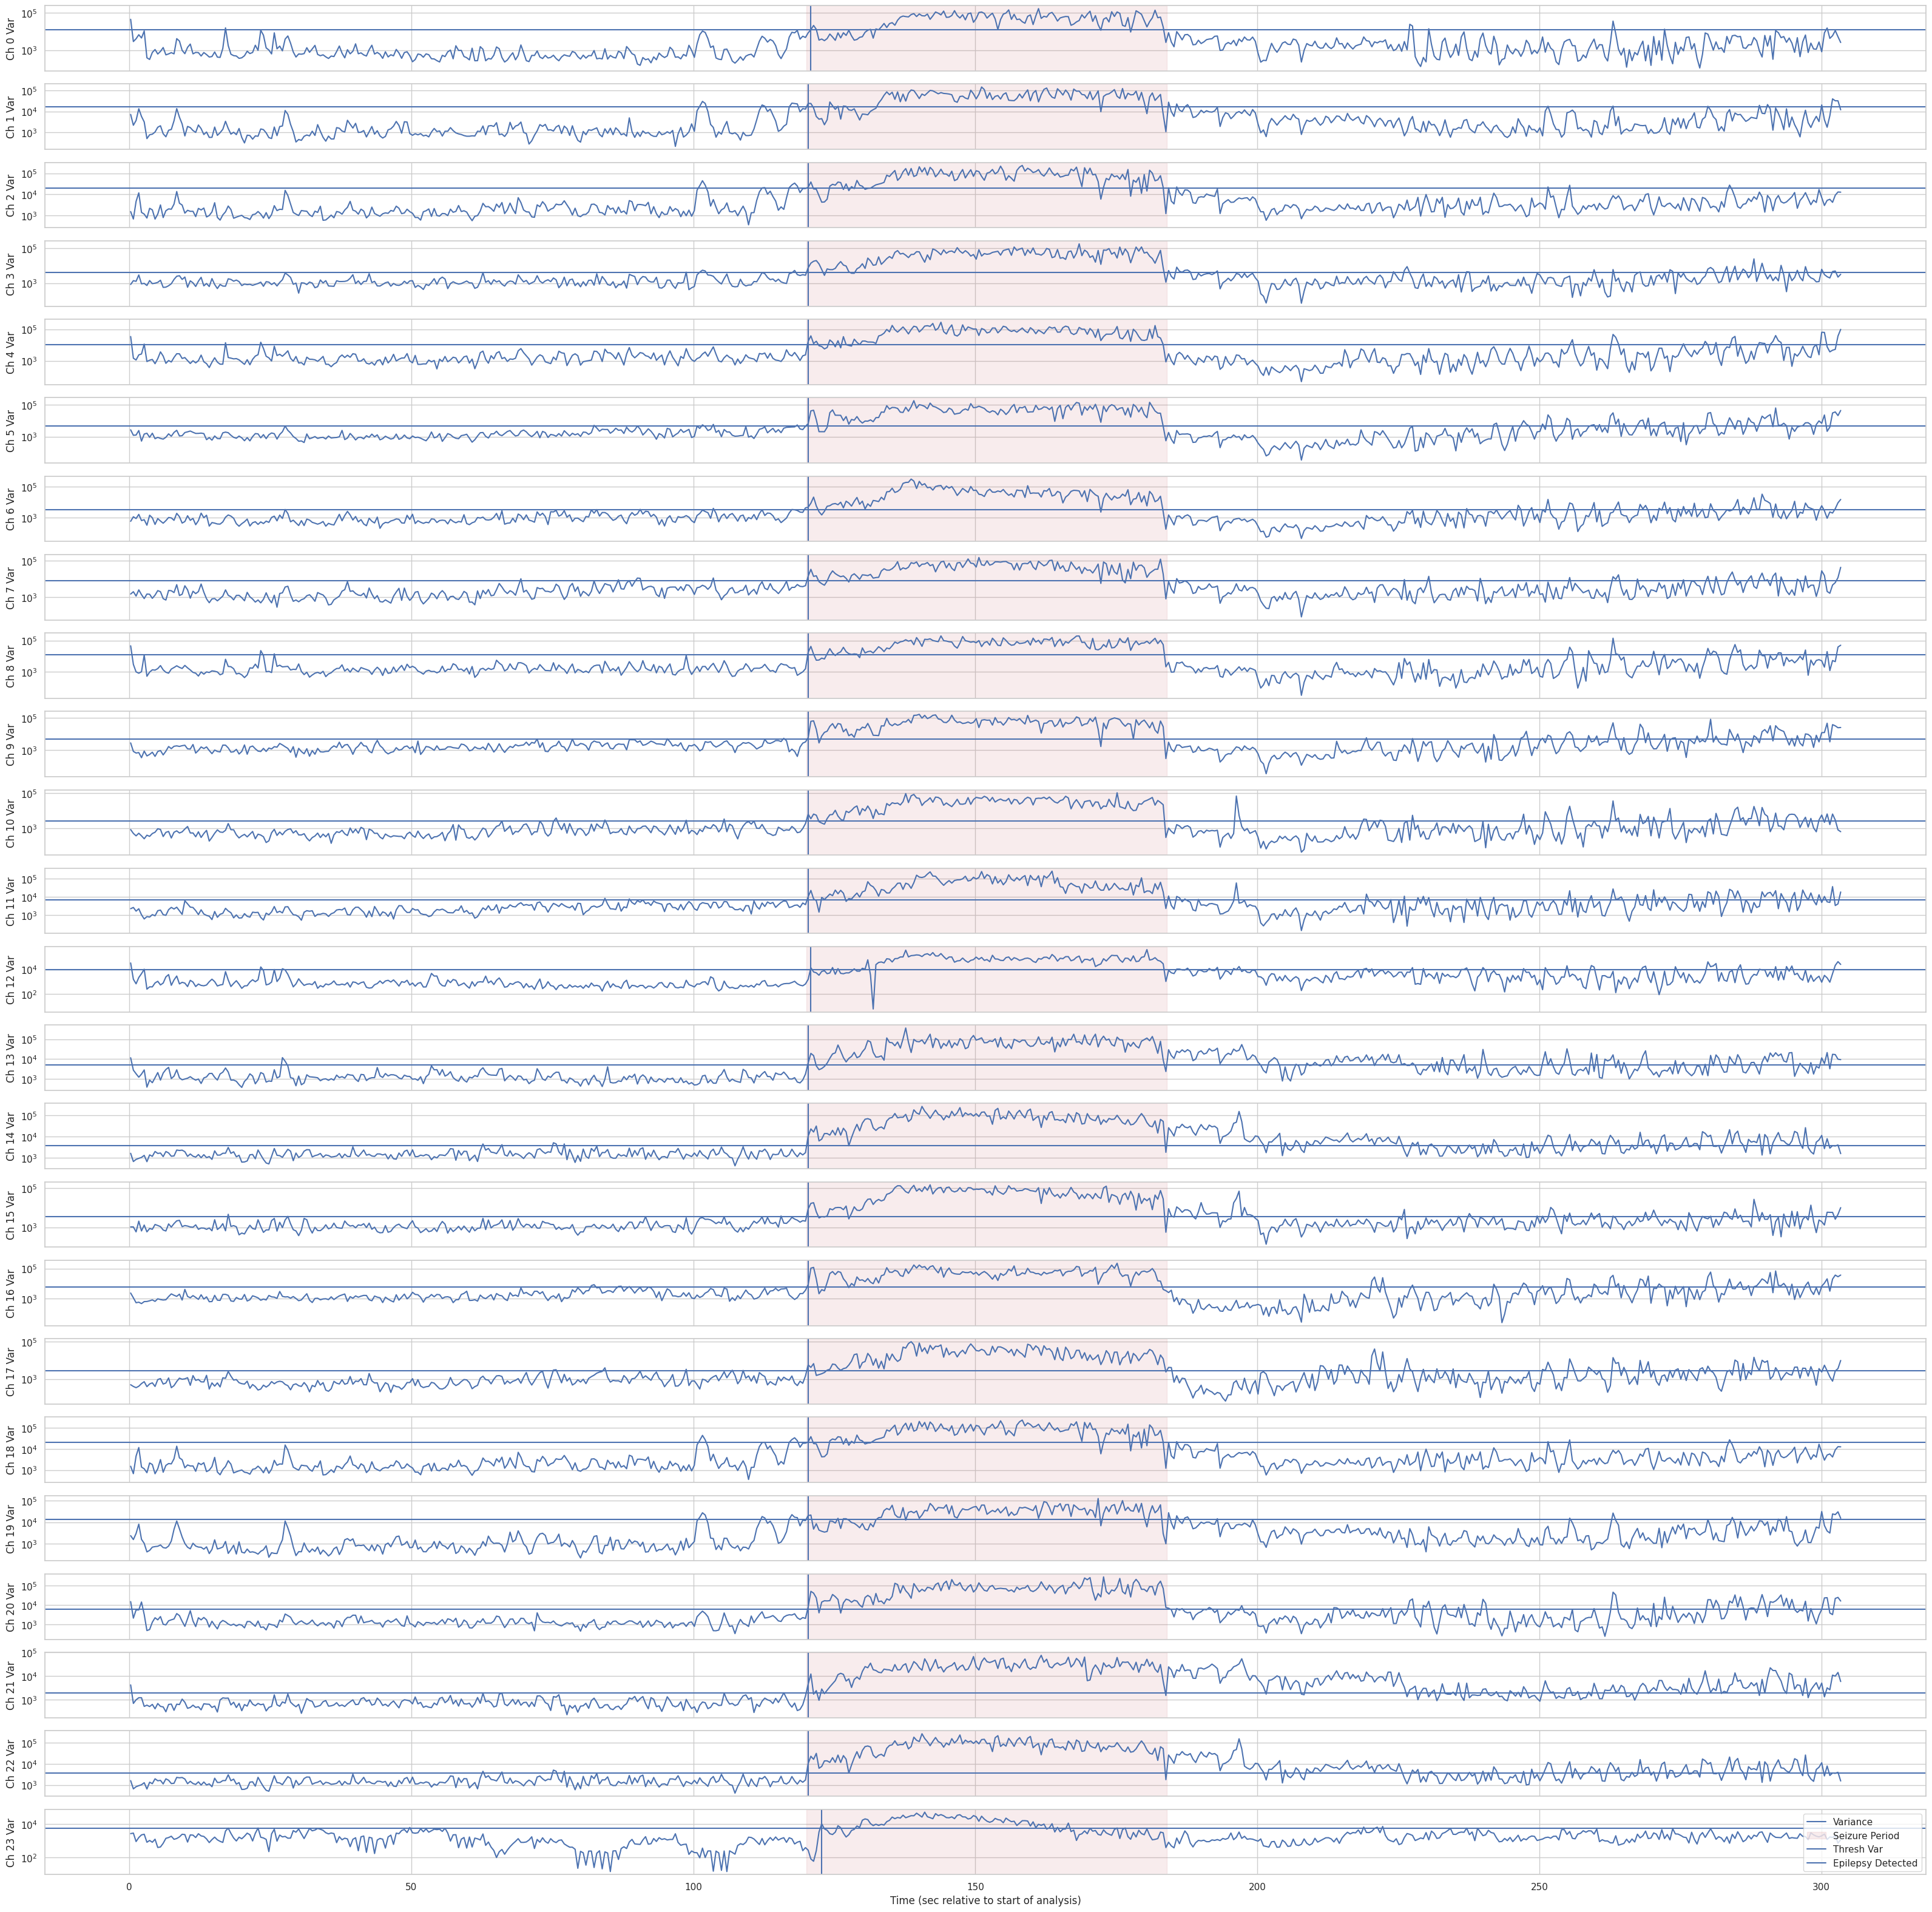

Resumen detección:
 channel      thr_var  detected  detection_time  detection_delay_s
       0 12193.728806      True      120.837891           0.837891
       1 16027.921403      True      120.357422           0.357422
       2 20384.380987      True      120.357422           0.357422
       3  4187.605863      True      120.357422           0.357422
       4 10286.687758      True      120.357422           0.357422
       5  4910.907159      True      120.357422           0.357422
       6  3444.145659      True      120.357422           0.357422
       7  8228.654574      True      120.357422           0.357422
       8 12554.905159      True      120.357422           0.357422
       9  4879.211404      True      120.357422           0.357422
      10  2494.225297      True      120.357422           0.357422
      11  7114.255736      True      120.357422           0.357422
      12  9557.460040      True      120.837891           0.837891
      13  5214.416062      True      120.35

In [ ]:
# Rutina: sliding_descriptor(signal, window_size, step, model)
# Precondición:
#   - signal es un array numérico 1D no vacío.
#   - window_size y step son enteros demostrando los pasos de muestra para la deteccion.
# Postcondición:
#   - Devuelve cinco arrays: times, variances, stds, autocorrs, covs.
#   - Cada array tiene una longitud igual al número de ventanas deslizantes.
#   - Los arrays contienen los descriptores calculados para cada ventana según el modelo.
# Invariante:
#   - Para cada ventana, siempre se calcula la varianza.
#   - Según el modelo, se calcula autocorrelación, desviación estándar o covarianza.
# Complejidad:
#   - Tiempo: O(N * window_size) por canal, solo se recorre y se toman los pasos de muestra de la precond.
# El procesamiento de ventanas deslizantes, requiere calcular estadísticas sobre cada segmento completo.
# Introducir aleatoriedad no reduciria la complejidad y podria afectar los umbrales de detección.

window_size = 123
step = 123
selected_model = 'var_std'


def sliding_descriptor(signal, window_size, step, model='var_autocorr'):
    variances, stds, autocorrs, covs, times = [], [], [], [], []
    for start in range(0, len(signal) - window_size + 1, step):
        win = signal[start:start + window_size]
        var = np.var(win)
        std = np.std(win)
        if len(win) > 1:
            mean_win = np.mean(win)
            autocov_lag0 = np.mean((win - mean_win) ** 2)
            autocov_lag1 = np.mean((win[:-1] - mean_win) * (win[1:] - mean_win))
            autocorr = autocov_lag1 / autocov_lag0 if autocov_lag0 != 0 else np.nan
        else:
            autocorr = np.nan

        variances.append(var)
        stds.append(std)
        autocorrs.append(autocorr)

        if model == 'var_cov':
            win_ref = win
            mean_win_ref = np.mean(win_ref)
            cov = np.mean((win - mean_win) * (win_ref - mean_win_ref)) if len(win) == len(win_ref) else np.nan
            covs.append(cov)
        else:
            covs.append(np.nan)

        times.append((start + window_size / 2) / fs)
    return np.array(times), np.array(variances), np.array(stds), np.array(autocorrs), np.array(covs)


fig, axs = plt.subplots(num_channels, 1, figsize=(40, 40), sharex=True)
if num_channels == 1:
    axs = [axs]

models = {
    'var_autocorr': 'Varianza + Autocorrelación',
    'var_std': 'Varianza + Desviación Estándar',
    'var_cov': 'Varianza + Covarianza'

}
print(f"Usando modelo: {models[selected_model]}")

detection_summary = []

for ch in range(num_channels):
    total_sig = segments[ch]['total']
    times, vars_, stds, autocorrs, covs = sliding_descriptor(total_sig, window_size, step, model=selected_model)

    ax = axs[ch]
    ax.plot(times, vars_, label='Variance')
    ax.axvspan(before_sec, before_sec + crisis_duration_sec, color='r', alpha=0.1, label='Seizure Period')
    ax.set_ylabel(f'Ch {ch} Var')
    ax.set_yscale('log')



    before_mask = times < before_sec
    before_vars = vars_[before_mask]
    if len(before_vars) > 0:
        mean_var_before = np.mean(before_vars)
        std_var_before = np.std(before_vars)
    else:
        mean_var_before, std_var_before = 0, 0
    thresh_var = mean_var_before + 3 * std_var_before
    ax.axhline(thresh_var, color='b', label='Thresh Var')

    detect_idx = []
    label = ''

    if selected_model == 'var_autocorr':
        before_autocorrs = autocorrs[before_mask]
        if len(before_autocorrs) > 0:
            mean_autocorr_before = np.mean(before_autocorrs)
            std_autocorr_before = np.std(before_autocorrs)
        detect_idx = np.where((times >= before_sec) & (vars_ > thresh_var))[0]
        label = 'Delay (var + autocorr)'

    elif selected_model == 'var_std':
        before_stds = stds[before_mask]
        if len(before_stds) > 0:
            mean_std_before = np.mean(before_stds)
            std_std_before = np.std(before_stds)
        detect_idx = np.where((times >= before_sec) & (vars_ > thresh_var))[0]
        label = 'Delay (var + std)'

    elif selected_model == 'var_cov':
        before_covs = covs[before_mask]
        if len(before_covs) > 0:
            mean_cov_before = np.mean(before_covs)
            std_cov_before = np.std(before_covs)
        detect_idx = np.where((times >= before_sec) & (vars_ > thresh_var))[0]
        label = 'Delay (var + cov)'


    if len(detect_idx) > 0:
        detect_time = times[detect_idx[0]]
        delay = detect_time - before_sec
        detected = True
        ax.axvline(detect_time, color='b', label='Epilepsy Detected')
    else:
        detect_time = np.nan
        delay = np.nan
        detected = False

    detection_summary.append({
        'channel': ch,
        'thr_var': thresh_var,
        'detected': detected,
        'detection_time': detect_time,
        'detection_delay_s': delay
    })

plt.xlabel('Time (sec relative to start of analysis)')
plt.legend()
plt.show()



det_df = pd.DataFrame(detection_summary)
print("Resumen detección:")
print(det_df.to_string(index=False))


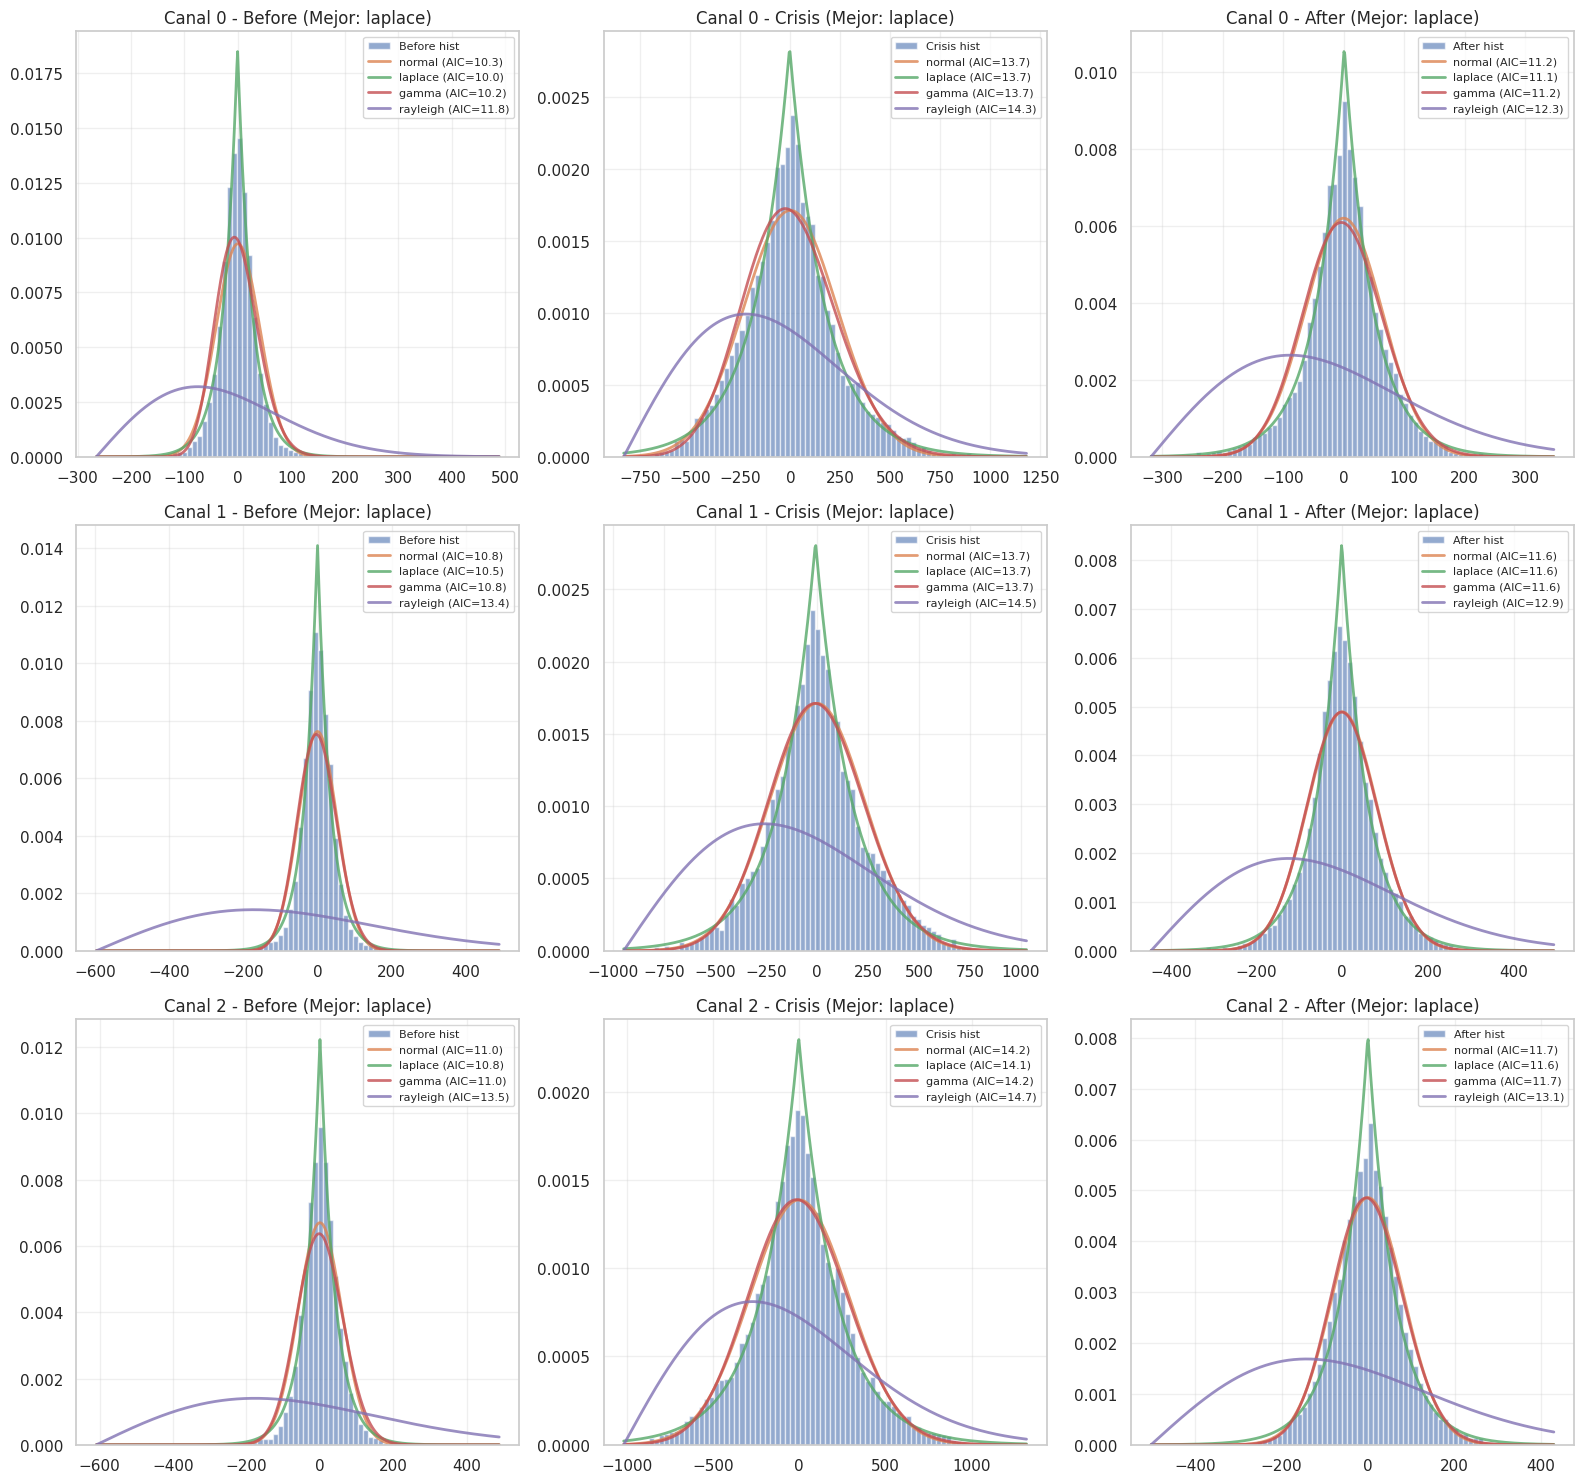


--- Canal 0 ---
  Estado Before:
    normal   -> AIC = 10.27, params = (np.float64(-3.4046839421838136e-16), np.float64(41.0378302411436))
    laplace  -> AIC = 9.97, params = (np.float64(-0.7525055962555968), np.float64(26.842478123728124))
    gamma    -> AIC = 10.24, params = (np.float64(45.51832345541682), np.float64(-271.7804312112361), np.float64(5.955037126166173))
    rayleigh -> AIC = 11.84, params = (-264.88878476943444, np.float64(189.53914082258666))
  Estado Crisis:
    normal   -> AIC = 13.74, params = (np.float64(3.885780586188048e-16), np.float64(233.2155365569177))
    laplace  -> AIC = 13.73, params = (np.float64(-4.066935668498169), np.float64(175.90091765873018))
    gamma    -> AIC = 13.73, params = (np.float64(82.3362843775842), np.float64(-2111.464862571789), np.float64(25.644402913924296))
    rayleigh -> AIC = 14.30, params = (-833.6345740467104, np.float64(612.1013353757576))
  Estado After:
    normal   -> AIC = 11.16, params = (np.float64(1.1842378929335002

In [ ]:
# Precondición:
#   - segments[ch][block] existe y contiene arrays numéricos 1D para cada canal y bloque ('before','crisis','after').
#   - Distribuciones a probar (norm, laplace, gamma, rayleigh) están importadas de scipy.stats.
# Postcondición:
#   - Se dibuja un histograma por canal y bloque con las PDFs ajustadas.
# Invariante:
#   - Para cada canal y bloque, se recorren todas las distribuciones de distributions_to_test.
# Complejidad:
#   - Tiempo: O(B * N), donde B = 3 bloques, N = número de muestras por bloque. Es decir,por cada bloque se recorre la lista de cada muestras
# El proceso requiere evaluar cada punto de datos para calcular los AICs de manera exacta.
# Por lo tanto introducir aleatoriedad comprometería la validez estadística de los ajustes.


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, laplace, gamma, rayleigh

sns.set(style="whitegrid")

distributions_to_test = [
    ('normal', norm),
    ('laplace', laplace),
    ('gamma', gamma),
    ('rayleigh', rayleigh)
]

n_hist = min(3, num_channels)
plt.figure(figsize=(16, 5*n_hist))

# Para guardar los AICs normalizados
results = {}

for i in range(n_hist):
    results[i] = {}
    for j, block in enumerate(['before','crisis','after']):
        data_block = segments[i][block].flatten()
        data_block = data_block[~np.isnan(data_block)]
        n = len(data_block)

        ax = plt.subplot(n_hist, 3, i*3 + j + 1)
        ax.hist(data_block, bins=80, alpha=0.6, density=True, label=f'{block.capitalize()} hist')

        best_aic = np.inf
        best_name = None
        best_params = None
        x = np.linspace(np.min(data_block), np.max(data_block), 500)

        results[i][block] = {}

        for name, dist in distributions_to_test:
            try:
                params = dist.fit(data_block)
                ll = np.sum(dist.logpdf(data_block, *params))
                aic = (2*len(params) - 2*ll) / n   # 🔹 AIC normalizado

                y = dist.pdf(x, *params)
                ax.plot(x, y, label=f'{name} (AIC={aic:.1f})', lw=2, alpha=0.8)

                results[i][block][name] = (aic, params)

                if aic < best_aic:
                    best_aic = aic
                    best_name = name
                    best_params = params
            except Exception:
                continue

        ax.set_title(f'Canal {i} - {block.capitalize()} (Mejor: {best_name})')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Mostrar resultados en consola
for i in results:
    print(f"\n--- Canal {i} ---")
    for block in results[i]:
        print(f"  Estado {block.capitalize()}:")
        for name, (aic, params) in results[i][block].items():
            print(f"    {name:8s} -> AIC = {aic:.2f}, params = {params}")


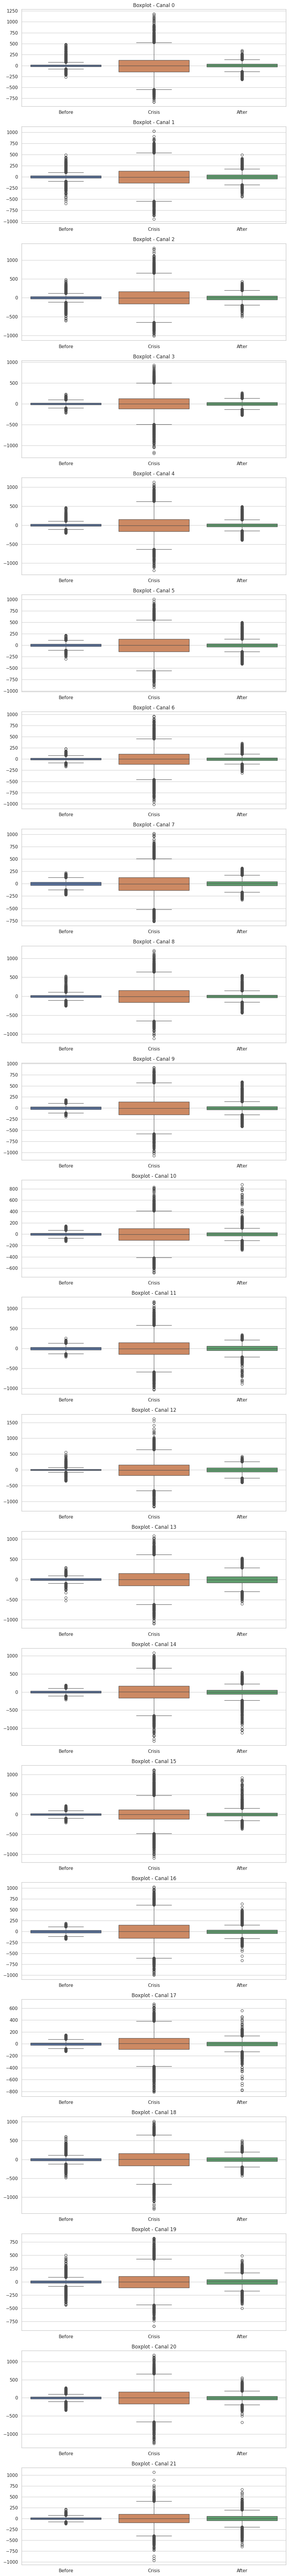

In [ ]:
# Precondición:
#   - segments[ch][block] existe y contiene arrays numéricos 1D para cada canal y bloque ('before','crisis','after').
#   - num_channels está definido.
# Postcondición:
#   - Se dibuja un boxplot por canal mostrando las distribuciones de los bloques 'before', 'crisis' y 'after'.
#   - No modifica los datos originales.
# Invariante:
#   - Para cada canal, siempre se procesan los mismos tres bloques.
# Complejidad:
#   - Tiempo: O(C * N), donde C = num_channels y N ≈ número máximo de muestras por bloque (para aplanar y graficar).
# La operación de boxplot requiere todos los puntos de datos lo que implica una complejidad O(C * N).
# Entonces la introduccion de aleatoriedad no mejoraria esta complejidad.

sns.set(style="whitegrid")
n_hist = min(22, num_channels)

plt.figure(figsize=(10, 4*n_hist))

for i in range(n_hist):
    before = segments[i]['before']
    crisis = segments[i]['crisis']
    after = segments[i]['after']

    ax = plt.subplot(n_hist, 1, i+1)
    sns.boxplot(data=[before.flatten(), crisis.flatten(), after.flatten()], orient='v', ax=ax)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Before', 'Crisis', 'After'])
    ax.set_title(f'Boxplot - Canal {i}')

plt.tight_layout()
plt.show()

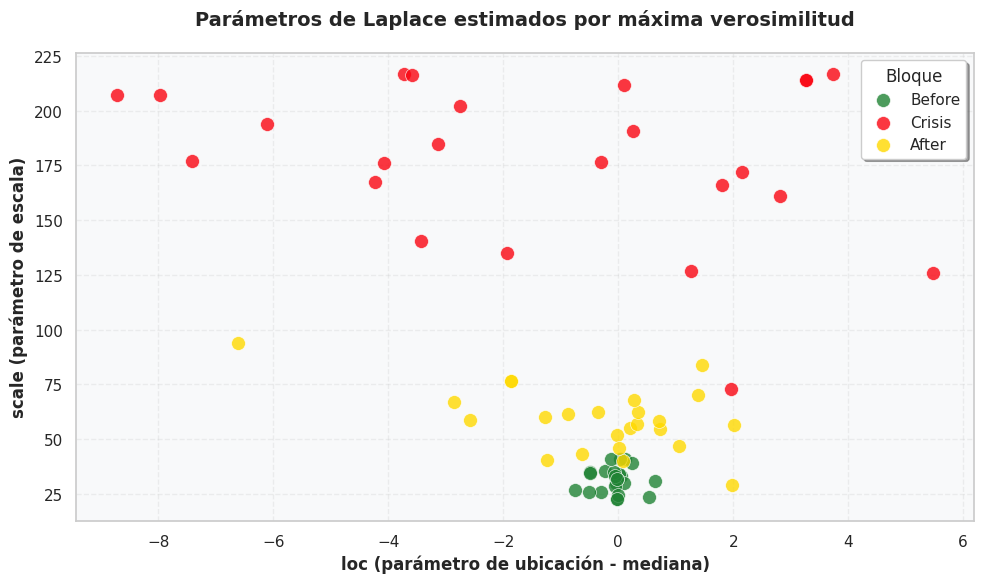

In [ ]:
# Precondición:
#   - segments[ch][block] existe y contiene arrays numéricos 1D para cada canal y bloque.
# Postcondición:
#   - Se genera un DataFrame con parámetros principales de Laplace (loc, scale) para cada canal y bloque.
#   - Se dibuja un scatterplot de los parámetros con colores que representan la secuencia temporal.
# Invariante:
#   - Cada entrada del DataFrame corresponde a un canal y bloque, con param1 (loc) y param2 (scale).
# Complejidad:
#   - Tiempo: O(B * F), B = 3 bloques, F ≈ tiempo de ajuste de Laplace. Lo mismo que antes, solo que ahora por cada bloque se hacen las variables de laplace
# Similar a lo anterior visto usar funciones random no mejoraría la complejidad computacional en este ajuste de Laplace
#

sns.set(style="whitegrid")

params_data = []
for i in range(num_channels):
    for block in ['before', 'crisis', 'after']:
        data_block = segments[i][block].flatten()
        data_block = data_block[~np.isnan(data_block)]


        loc, scale = laplace.fit(data_block)

        params_data.append({
            'channel': i,
            'block': block,
            'loc': loc,
            'scale': scale
        })

params_df = pd.DataFrame(params_data)

plt.figure(figsize=(10, 6))


color_palette = [ '#208334','#FA0511', '#FFD900']
block_colors = {block: color for block, color in zip(['before', 'crisis', 'after'], color_palette)}


for block, color in block_colors.items():
    block_data = params_df[params_df['block'] == block]
    plt.scatter(block_data['loc'], block_data['scale'],
                c=color, s=100, alpha=0.8, label=block.capitalize(),
                edgecolors='white', linewidth=0.5)

plt.xlabel('loc (parámetro de ubicación - mediana)', fontsize=12, fontweight='bold')
plt.ylabel('scale (parámetro de escala)', fontsize=12, fontweight='bold')
plt.title('Parámetros de Laplace estimados por máxima verosimilitud',
          fontsize=14, fontweight='bold', pad=20)


plt.legend(title='Bloque', title_fontsize=12, fontsize=11,
           frameon=True, fancybox=True, shadow=True)


plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f9fa')


plt.tight_layout()


if len(params_df) > 0:

    max_scale_idx = params_df['scale'].idxmax()
    max_point = params_df.loc[max_scale_idx]

plt.show()

